## 1. Defining Pitch Outcomes & The Strike Zone

In baseball, strikes are the optimal baseline outcome for a pitcher as they move the count closer to a strikeout. Pitchers achieve a called strike by throwing the baseball within the designated strike zone—defined in the rulebook as the area over home plate extending from the midpoint of the batter's shoulders and the top of their uniform pants, down to a point just below the kneecap.

### The Evolution of the Strike Zone
When analyzing historical Statcast data (prior to the 2026 MLB implementation of the Automated Ball-Strike system), the strike zone was determined in two dimensions based on visual estimation:
* **`sz_top`:** The distance in feet from the ground to the top of the current batter's strike zone. Historically, a PITCHf/x or Statcast operator set a visual line at the batter's belt as they settled into their hitting stance, and the software added four inches to establish the top of the zone.
* **`sz_bot`:** The distance in feet from the ground to the bottom of the current batter's strike zone, historically set by the operator at the hollow of the knee.

*(Note: As of 2026, the ABS Challenge System now defines the zone mathematically as exactly 53.5% of the batter's height for the top, and 27% for the bottom).*

### The Strategic Trade-Off
The strategy of throwing pitches in the strike zone comes with an inherent risk. While in-zone pitches generate called strikes, they also give the batter the opportunity to swing and make contact, potentially resulting in hits or advancing runners. Therefore, predicting the optimal pitch requires evaluating game context independent of just pitch physics.

### The Role of Game Context
* **Count Advantage:** If a hitter is in an advantageous count (e.g., 3-0, 2-1), they are more likely to wait for "their pitch"—a pitch in the heart of the zone designed for damage. Conversely, if a hitter is in a disadvantaged, two-strike count (e.g., 0-2, 1-2), they are forced to defend the plate and actively expand their swing decisions.
* **Base State (RISP):** The configuration of runners on base—especially runners in scoring position—drastically alters swing intent. Hitters tend to be much more aggressive when runners are on base to generate runs.

### Application Objective & Target Outcomes
The intended use of this application is to synthesize these contextual game states and pitch physics to predict the optimal pitch to throw in any given situation. 

The predictive engine is designed to maximize the probability of the three most favorable pitcher outcomes:
1. **Called Strike** (A strike with no swing)
2. **Whiff** (A swing and a miss)
3. **Low Damage** (A swing making contact, but resulting in a low expected run value, xwOBAcon)
    * **wOBA (Weighted On-Base Percentage):** A metric that values walks, hits, and home runs proportionally to their actual run-manufacturing value, rather than treating all hits or times-on-base equally like batting average or on-base percentage.
    * **xwOBAcon (Expected wOBA on Contact):** A metric focused exclusively on balls in play, completely removing defense, ballpark factors, and baseline foot speed. It utilizes the launch angle and exit velocity of the batted ball to calculate the expected run value of the contact based on historical league-wide outcomes.

## 2. How Many Swings?

Before modeling, we need a league-wide baseline: how often do hitters swing, and how does that split between pitches in the strike zone vs. outside it?

### Approach

**Swings** — Derived from Statcast `description`. A pitch counts as a swing when the batter offered at it:

- `swinging_strike`, `swinging_strike_blocked` (whiffs)
- `foul`, `foul_tip` (fouls)
- `hit_into_play`, `hit_into_play_no_out`, `hit_into_play_score` (balls in play)

Everything else (called strike, ball, hit by pitch, etc.) is a **take**.

**In-zone vs. out-of-zone** — We assign MLB Statcast zones from `plate_x`, `plate_z`, and each pitch's `sz_top` / `sz_bot` via `assign_statcast_zone` (same 13-zone grid as the app heatmap):

| `zone` values | Meaning |
|---|---|
| **1–9** | Heart — 3×3 grid inside the rule-book strike zone (Z-zone) |
| **11** | Top-left shadow (O-zone) |
| **12** | Top-right shadow |
| **13** | Bottom-left shadow |
| **14** | Bottom-right shadow |

Outer zones split at plate center (`x = 0`) and strike-zone midpoint (`z = (sz_top + sz_bot) / 2`). This matches the standard FanGraphs **Z-Swing%** / **O-Swing%** split (1–9 vs. 11–14). Pitches missing `plate_x` / `plate_z` are excluded from the in/out split but still count toward total pitches.

**Whiffs** — A subset of swings where the batter missed: `swinging_strike`, `swinging_strike_blocked`.

**Bunts** — `foul_bunt` and `missed_bunt` are **not** counted as swings in this project.

**League percentages**

- **Swing rate** = swings ÷ all pitches
- **Whiff rate** = whiffs ÷ swings (miss rate on swings only)
- **Z-Swing%** = swings on in-zone pitches ÷ in-zone pitches
- **O-Swing%** = swings on out-of-zone pitches ÷ out-of-zone pitches

**Descriptive statistics** — Computed **per batter**, then summarized. Metrics:

| Metric | Definition |
|---|---|
| **Swing Rate** | swings ÷ all pitches |
| **O-Zone Swing%** | swings ÷ O-zone pitches |
| **Z-Zone Swing%** | swings ÷ Z-zone pitches |
| **Whiff%** | whiffs ÷ swings |
| **O-Zone Whiff%** | whiffs ÷ O-zone swings |
| **Z-Zone Whiff%** | whiffs ÷ Z-zone swings |

**Mean vs. median** — Use **median** as the “typical hitter” benchmark. Per-batter rates are slightly right-skewed (part-time players with small samples pull the mean). **Mean** still appears in the table for comparison; it will sit closer to the pitch-weighted league bullets above, which treat every pitch equally rather than every batter.

In [1]:
import sys
from pathlib import Path  # capital P — not "path"

from IPython.display import display

print("Python:", sys.executable)

try:
    import pandas as pd
    import pyarrow  # noqa: F401 — required for read_parquet
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Wrong kernel — packages missing. Fix:\n"
        "  1. Click the kernel picker (top-right) → Portfolio (.venv)\n"
        "  2. Or run: .venv\\Scripts\\python.exe -m pip install -r requirements.txt\n"
        "  3. Restart kernel and run this cell again."
    ) from exc

print("pandas:", pd.__version__)

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
DATA_FILE = ROOT / "data" / "statcast_2025.parquet"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Statcast file not found at {DATA_FILE}\n"
        f"cwd={NB_DIR} — run 00_data_pull.ipynb first."
    )

print(f"Project root: {ROOT}")
print(f"Data file: {DATA_FILE}")
print("Setup OK — run the next cell for league swing counts.")

Python: c:\Users\tabshire\Desktop\Portfolio\.venv\Scripts\python.exe
pandas: 3.0.3
Project root: C:\Users\tabshire\Desktop\Portfolio
Data file: C:\Users\tabshire\Desktop\Portfolio\data\statcast_2025.parquet
Setup OK — run the next cell for league swing counts.


In [2]:
SWING_DESCRIPTIONS = {
    "swinging_strike",
    "swinging_strike_blocked",
    "foul",
    "foul_tip",
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score",
}

WHIFF_DESCRIPTIONS = {
    "swinging_strike",
    "swinging_strike_blocked",
}

IN_ZONE_ZONES = set(range(1, 10))
OUT_ZONE_ZONES = set(range(11, 15))

PITCH_CATEGORIES = {
    "Fastballs": ["FF", "SI", "FC"],
    "Vertical Breaking Balls": ["CU", "SV", "KC"],
    "Horizontal Breaking Balls": ["SL", "ST"],
    "Offspeed": ["CH", "FS"],
}

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.batter_zone_profiles import attach_statcast_zone

df = pd.read_parquet(DATA_FILE)
df = attach_statcast_zone(df)
df["is_swing"] = df["description"].isin(SWING_DESCRIPTIONS)
df["is_whiff"] = df["description"].isin(WHIFF_DESCRIPTIONS)
df["is_in_zone"] = df["zone"].isin(IN_ZONE_ZONES)
df["is_out_of_zone"] = df["zone"].isin(OUT_ZONE_ZONES)

n_pitches = len(df)
n_in_zone = int(df["is_in_zone"].sum())
n_out_zone = int(df["is_out_of_zone"].sum())
n_unknown_zone = int((~df["is_in_zone"] & ~df["is_out_of_zone"]).sum())
n_swings = int(df["is_swing"].sum())
n_whiffs = int(df["is_whiff"].sum())

in_zone = df[df["is_in_zone"]]
out_zone = df[df["is_out_of_zone"]]

n_z_swings = int(in_zone["is_swing"].sum())
n_o_swings = int(out_zone["is_swing"].sum())

z_swing_pct = 100.0 * n_z_swings / n_in_zone if n_in_zone else float("nan")
o_swing_pct = 100.0 * n_o_swings / n_out_zone if n_out_zone else float("nan")
swing_pct = 100.0 * n_swings / n_pitches
whiff_pct = 100.0 * n_whiffs / n_swings if n_swings else float("nan")

def fmt(n: int) -> str:
    return f"{n:,}"

print("2025 MLB regular season (Statcast)")
print(f"• Total pitches: {fmt(n_pitches)}")
print(f"• Pitches in the strike zone (zones 1–9): {fmt(n_in_zone)}")
print(f"• Pitches outside the strike zone (zones 11–14): {fmt(n_out_zone)}")
if n_unknown_zone:
    print(f"  (pitches with missing zone: {fmt(n_unknown_zone)})")
print(f"• Total swings: {fmt(n_swings)} ({swing_pct:.1f}%)")
print(f"  ◦ O-zone swings: {fmt(n_o_swings)} ({o_swing_pct:.1f}% of O-zone pitches)")
print(f"  ◦ Z-zone swings: {fmt(n_z_swings)} ({z_swing_pct:.1f}% of Z-zone pitches)")
print(f"• Total whiffs: {fmt(n_whiffs)} ({whiff_pct:.1f}% of swings)")

2025 MLB regular season (Statcast)
• Total pitches: 711,897
• Pitches in the strike zone (zones 1–9): 295,589
• Pitches outside the strike zone (zones 11–14): 416,308
• Total swings: 337,397 (47.4%)
  ◦ O-zone swings: 133,654 (32.1% of O-zone pitches)
  ◦ Z-zone swings: 203,743 (68.9% of Z-zone pitches)
• Total whiffs: 78,023 (23.1% of swings)


In [3]:
from IPython.display import display  # also imported in Setup

# Per-batter rates → descriptive summary (mean + median)
batter_rates = df.groupby("batter", as_index=False).agg(
    swing_rate=("is_swing", "mean"),
    pitches=("is_swing", "size"),
)

whiff_rates = (
    df[df["is_swing"]]
    .groupby("batter", as_index=False)
    .agg(whiff_rate=("is_whiff", "mean"), swings=("is_whiff", "size"))
)

z_swing_rates = (
    in_zone.groupby("batter", as_index=False)
    .agg(z_swing_rate=("is_swing", "mean"), z_pitches=("is_swing", "size"))
)
o_swing_rates = (
    out_zone.groupby("batter", as_index=False)
    .agg(o_swing_rate=("is_swing", "mean"), o_pitches=("is_swing", "size"))
)

o_whiff_rates = (
    out_zone[out_zone["is_swing"]]
    .groupby("batter", as_index=False)
    .agg(o_whiff_rate=("is_whiff", "mean"), o_swings=("is_whiff", "size"))
)
z_whiff_rates = (
    in_zone[in_zone["is_swing"]]
    .groupby("batter", as_index=False)
    .agg(z_whiff_rate=("is_whiff", "mean"), z_swings=("is_whiff", "size"))
)

batter_rates = (
    batter_rates
    .merge(whiff_rates, on="batter", how="left")
    .merge(z_swing_rates, on="batter", how="left")
    .merge(o_swing_rates, on="batter", how="left")
    .merge(o_whiff_rates, on="batter", how="left")
    .merge(z_whiff_rates, on="batter", how="left")
)

SWING_METRICS = {
    "swing_rate": "Swing Rate",
    "o_swing_rate": "O-Zone Swing%",
    "z_swing_rate": "Z-Zone Swing%",
}

WHIFF_METRICS = {
    "whiff_rate": "Whiff%",
    "o_whiff_rate": "O-Zone Whiff%",
    "z_whiff_rate": "Z-Zone Whiff%",
}


def summarize_rates(frame: pd.DataFrame, metrics: dict[str, str]) -> pd.DataFrame:
    rows = []
    for col, label in metrics.items():
        s = frame[col].dropna()
        rows.append(
            {
                "Metric": label,
                "n batters": len(s),
                "mean": s.mean() * 100,
                "median": s.median() * 100,
                "std": s.std(ddof=1) * 100,
                "min": s.min() * 100,
                "max": s.max() * 100,
            }
        )
    return pd.DataFrame(rows).round(1).set_index("Metric")


swing_desc = summarize_rates(batter_rates, SWING_METRICS)
whiff_desc = summarize_rates(batter_rates, WHIFF_METRICS)

print("Swing rates (per batter)")
display(swing_desc)

print("\nWhiff rates (per batter)")
display(whiff_desc)

Swing rates (per batter)


,n batters,mean,median,std,min,max
Metric,,,,,,
Swing Rate,673,48.1,47.8,6.5,0.0,78.9
O-Zone Swing%,672,33.2,32.7,8.3,0.0,100.0
Z-Zone Swing%,673,68.6,68.9,9.8,0.0,100.0



Whiff rates (per batter)


,n batters,mean,median,std,min,max
Metric,,,,,,
Whiff%,672,24.9,23.8,10.0,0.0,100.0
O-Zone Whiff%,669,39.3,38.8,13.6,0.0,100.0
Z-Zone Whiff%,668,15.3,14.2,8.7,0.0,100.0


## 3. What Are They Swinging At?

Not every pitch is the same. A slider away and a fastball up-and-in live in different parts of the zone and draw different swing decisions. Statcast tags each pitch with a **`pitch_type`** code and a plain-English **`pitch_name`**.

### Pitch types in this dataset

| Code | Layman's name | Category (storytelling) |
|------|---------------|-------------------------|
| **FF** | 4-Seam Fastball | Fastballs |
| **SI** | Sinker | Fastballs |
| **FC** | Cutter | Fastballs |
| **SL** | Slider | Horizontal Breaking Balls |
| **ST** | Sweeper | Horizontal Breaking Balls |
| **CU** | Curveball | Vertical Breaking Balls |
| **SV** | Slurve | Vertical Breaking Balls |
| **KC** | Knuckle Curve | Vertical Breaking Balls |
| **CH** | Changeup | Offspeed |
| **FS** | Splitter | Offspeed |

Rare or non-competitive codes also appear in the raw pull (eephus, knuckleball, pitch-out, etc.) but are **not** included in the category summary below.

### Categories vs. the model

For **storytelling and EDA**, we group pitches into four buckets — **Fastballs**, **Vertical Breaking Balls** (CU, SV, KC), **Horizontal Breaking Balls** (SL, ST), and **Offspeed** — so patterns are easy to read.

For **modeling**, we keep the granular **`pitch_type`** code (FF, SL, ST, …). The model learns pitch-specific physics and swing behavior.

### Category summary (2025 league)

Each row is all pitches of that category. **In-Zone %** and **Out-of-Zone %** use Statcast zones 1–9 and 11–14 (same as Section 2). **Z-Swing %** and **O-Swing %** are swing rates on in-zone and out-of-zone pitches within that category.

In [4]:
# Section 3 — pitch category summary (requires Setup + load cell above)
try:
    df
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell, then the data load cell (Section 2), before this cell."
    ) from exc

print("Building pitch category table…")

code_to_category = {
    code: category for category, codes in PITCH_CATEGORIES.items() for code in codes
}

pitch_category = df["pitch_type"].map(code_to_category)

rows = []
for category in PITCH_CATEGORIES:
    g = df[pitch_category == category]
    in_z = g["is_in_zone"]
    out_z = g["is_out_of_zone"]
    rows.append(
        {
            "Category": category,
            "Pitches": len(g),
            "In-Zone %": 100.0 * in_z.mean(),
            "Out-of-Zone %": 100.0 * out_z.mean(),
            "Z-Swing %": 100.0 * g.loc[in_z, "is_swing"].mean() if in_z.any() else float("nan"),
            "O-Swing %": 100.0 * g.loc[out_z, "is_swing"].mean() if out_z.any() else float("nan"),
        }
    )

pitch_category_summary = pd.DataFrame(rows).set_index("Category")
pitch_category_summary["Pitches"] = pitch_category_summary["Pitches"].map(lambda n: f"{n:,}")
for col in ["In-Zone %", "Out-of-Zone %", "Z-Swing %", "O-Swing %"]:
    pitch_category_summary[col] = pitch_category_summary[col].round(1)

print("Done.\n")
print(pitch_category_summary.to_string())

Building pitch category table…
Done.

                           Pitches  In-Zone %  Out-of-Zone %  Z-Swing %  O-Swing %
Category                                                                          
Fastballs                  389,612       47.0           53.0       68.5       29.2
Vertical Breaking Balls     63,738       35.4           64.6       59.8       32.3
Horizontal Breaking Balls  156,310       37.9           62.1       68.7       34.8
Offspeed                    96,391       30.7           69.3       78.8       38.1


## 4. Pitch Physics by Handedness

Beyond location and count, **pitch physics** shape swing-and-miss. Statcast tracks each offering from release to the plate. Four fields drive most of the story:

| Statcast column | Layman's term | What it means |
|---|---|---|
| **`release_speed`** | Velocity | How fast the ball leaves the pitcher's hand (mph). Higher velo generally shrinks reaction time. |
| **`release_spin_rate`** | Spin rate | How fast the ball spins (rpm). More spin can amplify movement and ride on fastballs, or sharpen break on sliders and curves. |
| **`pfx_z`** | Vertical movement | How much the ball rises or drops vs. a spinless pitch, in **inches** (positive = more rise, negative = more drop). |
| **`pfx_x`** | Horizontal movement | Side-to-side break vs. a spinless pitch, in **inches**, from the **catcher's view** (sign flips by pitcher handedness). |

Tables below use the same **pitch categories** as Section 3, split by **`p_throws`** (`R` / `L`). Values are **medians** — the typical pitch in that bucket — which stay stable when a few extreme outliers (position-player lobs, misreads) sit in the data.

Movement is reported in Statcast's normalized `pfx_x` / `pfx_z` frame, so compare horizontal break **within** a handedness table, not across RHP vs. LHP rows.

In [5]:
# Section 4 — physics by pitch category and pitcher handedness
try:
    df
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell, then the data load cell (Section 2), before this cell."
    ) from exc

PHYSICS_FIELDS = {
    "release_speed": "Velocity (mph)",
    "release_spin_rate": "Spin rate (rpm)",
    "pfx_z": "Vertical movement (in)",
    "pfx_x": "Horizontal movement (in)",
}

code_to_category = {
    code: category for category, codes in PITCH_CATEGORIES.items() for code in codes
}
physics_df = df[df["pitch_type"].map(code_to_category).notna() & df["p_throws"].isin(["R", "L"])].copy()
physics_df["pitch_category"] = physics_df["pitch_type"].map(code_to_category)


def physics_summary(hand: str) -> pd.DataFrame:
    subset = physics_df[physics_df["p_throws"] == hand]
    rows = []
    for category in PITCH_CATEGORIES:
        g = subset[subset["pitch_category"] == category]
        row = {"Category": category}
        for col, label in PHYSICS_FIELDS.items():
            row[label] = g[col].median()
        rows.append(row)

    table = pd.DataFrame(rows).set_index("Category")
    table["Velocity (mph)"] = table["Velocity (mph)"].round(1)
    table["Spin rate (rpm)"] = table["Spin rate (rpm)"].round(0).astype("Int64")
    table["Vertical movement (in)"] = table["Vertical movement (in)"].round(2)
    table["Horizontal movement (in)"] = table["Horizontal movement (in)"].round(2)
    return table


print("Right-handed pitchers (median)")
display(physics_summary("R"))

print("\nLeft-handed pitchers (median)")
display(physics_summary("L"))

Right-handed pitchers (median)


,Velocity (mph),Spin rate (rpm),Vertical movement (in),Horizontal movement (in)
Category,,,,
Fastballs,94.300003,2316,1.13,-0.73
Vertical Breaking Balls,80.900002,2597,-0.87,0.75
Horizontal Breaking Balls,85.599998,2518,0.13,0.51
Offspeed,86.900002,1697,0.31,-1.17



Left-handed pitchers (median)


,Velocity (mph),Spin rate (rpm),Vertical movement (in),Horizontal movement (in)
Category,,,,
Fastballs,92.699997,2251,1.13,0.80
Vertical Breaking Balls,79.599998,2483,-0.78,-0.68
Horizontal Breaking Balls,84.000000,2400,0.14,-0.46
Offspeed,84.699997,1702,0.43,1.19


## 5. Where Are They Throwing It?

Location is the third pillar after pitch type and physics. Each pitch has a **`plate_x`** / **`plate_z`** crossing (feet, catcher's view) and a hitter-specific rule-book zone (`sz_top`, `sz_bot`).

### Attack zones (Heart · Shadow · Chase · Waste)

We bucket every pitch by its **signed distance to the nearest strike-zone edge** (in inches). Positive = inside the rule-book zone; negative = outside.

| Zone | Signed distance to edge | Plain English |
|------|-------------------------|---------------|
| **Heart** | **> 2 in** inside | Middle of the zone — the "middle-middle" target. |
| **Shadow** | **−2 to +2 in** | On the edge or just off — competitive framing / edges. |
| **Chase** | **−4 to −2 in** outside | Just off the plate — chase territory. |
| **Waste** | **< −4 in** outside | Nowhere near the zone — bait or mistakes. |

**Strike-zone frame:** 17 in wide (`|plate_x| ≤ 8.5 in`) × hitter height (`sz_bot` → `sz_top`).

### Attack zone map (reference)

One chart below shows **all four tiers** on a league-median strike zone — same axes and frame as the pitch-location plots, but **no pitch density**. Use it to read Heart / Shadow / Chase / Waste before the category heatmaps.

### Pitch locations by category

The next four panels overlay **2025 pitch density** by category on that same frame (all pitcher hands combined).

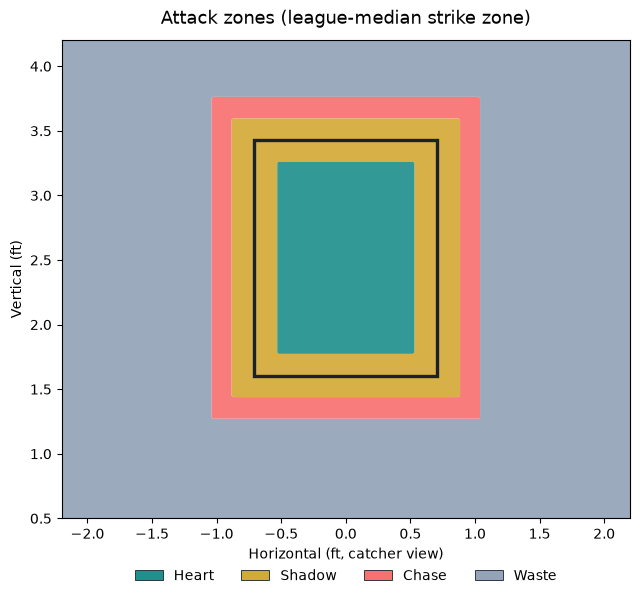

In [6]:
# Section 5a — attack zone reference (one plot, all four tiers)
try:
    df
except NameError as exc:
    raise RuntimeError("Run the Setup cell and the data load cell (Section 2) before this cell.") from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle

from src.attack_zones import ZONE_HALF_WIDTH_FT, ZONE_ORDER, assign_attack_zone

X_LIM = (-2.2, 2.2)
Z_LIM = (0.5, 4.2)
GRID_N = 200

loc_cols = df[["plate_x", "plate_z", "sz_top", "sz_bot"]].dropna()
SZ_TOP = float(loc_cols["sz_top"].median())
SZ_BOT = float(loc_cols["sz_bot"].median())

ZONE_COLORS = {
    "Heart": "#20908d",
    "Shadow": "#d4a937",
    "Chase": "#f87171",
    "Waste": "#94a3b8",
}
ZONE_CODE = {"Waste": 0, "Chase": 1, "Shadow": 2, "Heart": 3}

x = np.linspace(X_LIM[0], X_LIM[1], GRID_N)
z = np.linspace(Z_LIM[0], Z_LIM[1], GRID_N)
xx, zz = np.meshgrid(x, z)
zone_names = np.vectorize(assign_attack_zone)(xx, zz, SZ_TOP, SZ_BOT)
zone_codes = np.vectorize(ZONE_CODE.get)(zone_names).astype(float)

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="white")
ax.set_facecolor("#ffffff")

ax.contourf(
    xx,
    zz,
    zone_codes,
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
    colors=[ZONE_COLORS[z] for z in ["Waste", "Chase", "Shadow", "Heart"]],
    alpha=0.92,
    antialiased=True,
)

ax.add_patch(
    Rectangle(
        (-ZONE_HALF_WIDTH_FT, SZ_BOT),
        2 * ZONE_HALF_WIDTH_FT,
        SZ_TOP - SZ_BOT,
        fill=False,
        edgecolor="#1a202c",
        linewidth=2.4,
        zorder=4,
    )
)

ax.set_xlim(*X_LIM)
ax.set_ylim(*Z_LIM)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Horizontal (ft, catcher view)")
ax.set_ylabel("Vertical (ft)")
ax.set_title("Attack zones (league-median strike zone)", fontsize=13, pad=12)
ax.grid(False)

legend_handles = [
    Patch(facecolor=ZONE_COLORS[z], edgecolor="#1a202c", linewidth=0.6, label=z) for z in ZONE_ORDER
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)

plt.tight_layout()
plt.show()

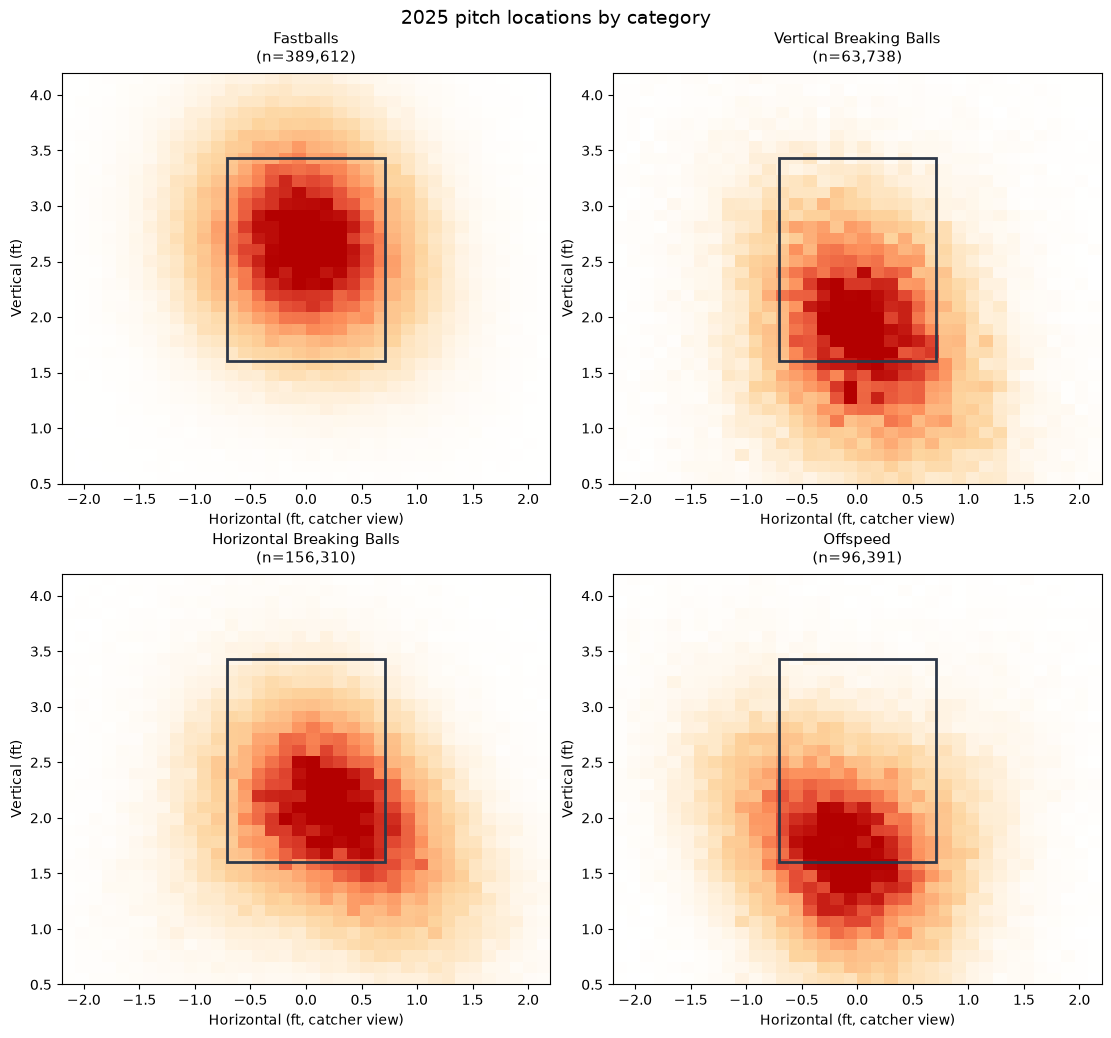

In [7]:
# Section 5b — pitch location heatmaps by category
try:
    df
    PITCH_CATEGORIES
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

from src.attack_zones import ZONE_HALF_WIDTH_FT

code_to_category = {
    code: category for category, codes in PITCH_CATEGORIES.items() for code in codes
}

loc = df[
    df["pitch_type"].map(code_to_category).notna()
    & df[["plate_x", "plate_z"]].notna().all(axis=1)
].copy()
loc["pitch_category"] = loc["pitch_type"].map(code_to_category)

SZ_TOP = float(loc["sz_top"].median())
SZ_BOT = float(loc["sz_bot"].median())

X_LIM = (-2.2, 2.2)
Z_LIM = (0.5, 4.2)
BINS = 36

# Light background → warm highlight (no black/purple tail)
HEAT_CMAP = LinearSegmentedColormap.from_list(
    "pitch_density",
    ["#ffffff", "#fff7ec", "#fee8c8", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"],
    N=256,
)


def draw_strike_zone(ax: plt.Axes) -> None:
    ax.add_patch(
        Rectangle(
            (-ZONE_HALF_WIDTH_FT, SZ_BOT),
            2 * ZONE_HALF_WIDTH_FT,
            SZ_TOP - SZ_BOT,
            fill=False,
            edgecolor="#2d3748",
            linewidth=2.0,
            zorder=3,
        )
    )


def plot_category_heatmap(ax: plt.Axes, category: str) -> None:
    subset = loc[loc["pitch_category"] == category]
    counts, xedges, zedges = np.histogram2d(
        subset["plate_x"],
        subset["plate_z"],
        bins=BINS,
        range=[X_LIM, Z_LIM],
    )
    vmax = float(np.percentile(counts[counts > 0], 98)) if np.any(counts > 0) else 1.0

    ax.set_facecolor("#fafafa")
    ax.pcolormesh(
        xedges,
        zedges,
        counts.T,
        cmap=HEAT_CMAP,
        vmin=0,
        vmax=vmax,
        shading="flat",
        zorder=1,
    )
    draw_strike_zone(ax)
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Z_LIM)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{category}\n(n={len(subset):,})", fontsize=11, pad=8)
    ax.set_xlabel("Horizontal (ft, catcher view)")
    ax.set_ylabel("Vertical (ft)")
    ax.grid(False)


fig, axes = plt.subplots(2, 2, figsize=(11, 10), facecolor="white", constrained_layout=True)

for ax, category in zip(axes.ravel(), PITCH_CATEGORIES):
    plot_category_heatmap(ax, category)

fig.suptitle("2025 pitch locations by category", fontsize=14, y=1.02)
plt.show()

## 6. Location × Outcomes

How does **where** the pitch is thrown relate to **swing** and **contact**?

### By pitch category × attack zone

Four tables — one per pitch category. Rows are **Heart / Shadow / Chase / Waste** (rule-book zone tiers from Section 5). Columns:

| Column | Definition |
|--------|------------|
| **Pitches** | Count in that tier |
| **Swing %** | swings ÷ pitches |
| **Contact %** | contact ÷ pitches (fouls + balls in play; whiffs excluded) |

### By height and plate side (all pitches)

Two league tables using **every pitch** with valid location:

**Vertical (Low / Middle / High)** — from `plate_z` vs. the hitter's `sz_top` / `sz_bot`.

**Horizontal (Inside / Middle / Outside)** — from `plate_x` and batter **`stand`** (inside/outside from the hitter's perspective).

Both include **Swing %**, **O-Zone Swing %**, and **Z-Zone Swing %** (same zone split as Section 2).


### League xwOBAcon by Statcast zone

At the end of this section, a **13-zone heatmap** shows league-average **xwOBAcon** on contact by Statcast zone (blue → white → red vs. league average).


In [8]:
# Section 6 — location outcome tables
try:
    df
    PITCH_CATEGORIES
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display

import importlib
import src.attack_zones as attack_zones

importlib.reload(attack_zones)
HORIZONTAL_ORDER = attack_zones.HORIZONTAL_ORDER
VERTICAL_ORDER = attack_zones.VERTICAL_ORDER
ZONE_ORDER = attack_zones.ZONE_ORDER
add_attack_zones = attack_zones.add_attack_zones

code_to_category = {
    code: category for category, codes in PITCH_CATEGORIES.items() for code in codes
}

work = df.copy()
work["pitch_category"] = work["pitch_type"].map(code_to_category)
work["is_contact"] = work["is_swing"] & ~work["is_whiff"]
work = add_attack_zones(work)


def attack_zone_outcomes(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for zone in ZONE_ORDER:
        g = frame[frame["attack_zone"] == zone]
        rows.append(
            {
                "Zone": zone,
                "Pitches": len(g),
                "Swing %": 100.0 * g["is_swing"].mean() if len(g) else float("nan"),
                "Contact %": 100.0 * g["is_contact"].mean() if len(g) else float("nan"),
            }
        )
    out = pd.DataFrame(rows).set_index("Zone")
    out["Pitches"] = out["Pitches"].map(lambda n: f"{int(n):,}")
    return out[["Pitches", "Swing %", "Contact %"]].round(1)


def location_swing_table(frame: pd.DataFrame, tier_col: str, tier_order: list[str]) -> pd.DataFrame:
    rows = []
    for tier in tier_order:
        g = frame[frame[tier_col] == tier]
        in_z = g[g["is_in_zone"]]
        out_z = g[g["is_out_of_zone"]]
        rows.append(
            {
                "Tier": tier,
                "Pitches": len(g),
                "Swing %": 100.0 * g["is_swing"].mean() if len(g) else float("nan"),
                "O-Zone Swing %": 100.0 * out_z["is_swing"].mean() if len(out_z) else float("nan"),
                "Z-Zone Swing %": 100.0 * in_z["is_swing"].mean() if len(in_z) else float("nan"),
            }
        )
    out = pd.DataFrame(rows).set_index("Tier")
    out["Pitches"] = out["Pitches"].map(lambda n: f"{int(n):,}")
    return out[["Pitches", "Swing %", "O-Zone Swing %", "Z-Zone Swing %"]].round(1)


for category in PITCH_CATEGORIES:
    cat_df = work[work["pitch_category"] == category]
    print(f"\n{category} — attack zone outcomes")
    display(attack_zone_outcomes(cat_df))

loc_all = work[work[["plate_x", "plate_z", "sz_top", "sz_bot"]].notna().all(axis=1)].copy()

print("\nAll pitches — vertical location (Low / Middle / High)")
display(location_swing_table(loc_all, "vertical_tier", VERTICAL_ORDER))

horiz_all = loc_all[loc_all["horizontal_tier"].isin(HORIZONTAL_ORDER)].copy()
print("\nAll pitches — horizontal location (Inside / Middle / Outside)")
display(location_swing_table(horiz_all, "horizontal_tier", HORIZONTAL_ORDER))




Fastballs — attack zone outcomes


,Pitches,Swing %,Contact %
Zone,,,
Heart,"128,766",72.0,63.7
Shadow,"105,356",55.5,45.8
Chase,"44,316",38.3,28.7
Waste,"111,174",15.9,9.9



Vertical Breaking Balls — attack zone outcomes


,Pitches,Swing %,Contact %
Zone,,,
Heart,"15,468",61.1,54.6
Shadow,"14,106",54.1,42.3
Chase,"6,611",44.1,28.3
Waste,"27,553",24.6,8.3



Horizontal Breaking Balls — attack zone outcomes


...

,Pitches,Swing %,Contact %
Zone,,,
Heart,"19,097",80.9,67.3
Shadow,"21,809",71.4,53.6
Chase,"11,309",57.7,37.3
Waste,"44,176",25.4,12.0



All pitches — vertical location (Low / Middle / High)


,Pitches,Swing %,O-Zone Swing %,Z-Zone Swing %
Tier,,,,
Low,"354,497",44.6,33.1,65.9
Middle,"106,757",60.2,38.8,72.1
High,"248,030",46.4,29.2,70.5



All pitches — horizontal location (Inside / Middle / Outside)


,Pitches,Swing %,O-Zone Swing %,Z-Zone Swing %
Tier,,,,
Inside,"190,885",46.0,34.7,69.1
Middle,"217,413",63.0,42.3,72.7
Outside,"300,986",37.4,27.6,62.2


### League xwOBAcon by Statcast zone

Thirteen-zone MLB grid (same geometry as Section 2 and the app heatmap). Each tile shows mean **xwOBAcon** on balls in play in 2025. Color runs **blue** (below average) → **white** (average) → **red** (above average).


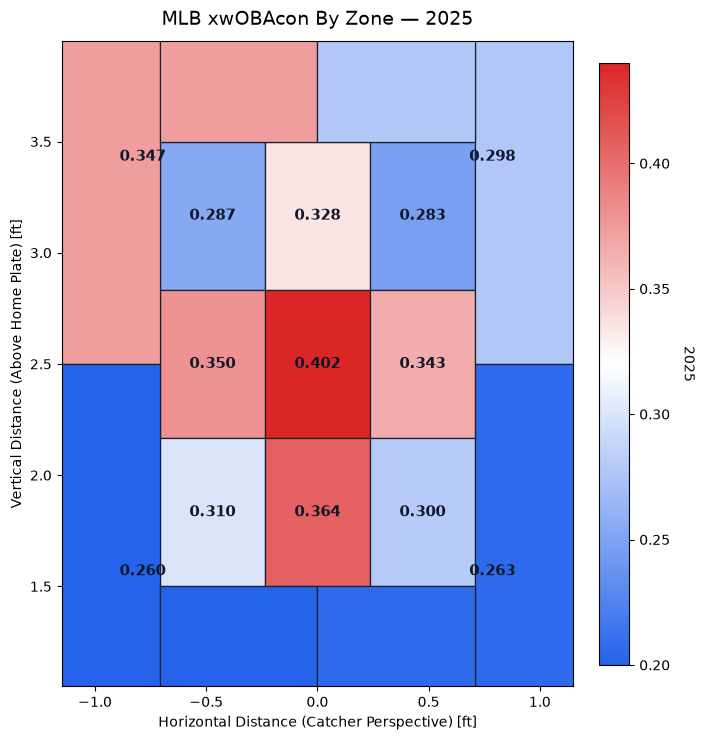

In [9]:
# Section 6b — league xwOBAcon by Statcast zone
try:
    df
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from src.batter_zone_profiles import LEAGUE_ZONE_XWOBAcon, attach_statcast_zone
from src.plot_style import plot_statcast_zone_heatmap

XWOBA_GRADIENT_SPAN = 0.12

bip = df.loc[df["estimated_woba_using_speedangle"].notna()].copy()
bip["xwobacon"] = pd.to_numeric(bip["estimated_woba_using_speedangle"], errors="coerce")
bip = attach_statcast_zone(bip)
zone_xwoba = bip.groupby("zone")["xwobacon"].mean().to_dict()

fig, _ = plot_statcast_zone_heatmap(
    zone_xwoba,
    title="MLB xwOBAcon By Zone — 2025",
    center=LEAGUE_ZONE_XWOBAcon,
    span=XWOBA_GRADIENT_SPAN,
)
plt.show()


## 7. When Are They Swinging?

Count leverage changes how wide the effective strike zone feels. The next cell prints the narrative with **live 2025 rates**, then three tables:

| Group | Counts |
|-------|--------|
| **Hitter advantage** | 1-0, 2-0, 3-0, 2-1, 3-1 |
| **Even** | 0-0, 1-1, 2-2, 3-2 |
| **Pitcher advantage** | 0-1, 0-2, 1-2 |

**Z-Swing %** and **O-Swing %** use Statcast zones 1–9 and 11–14 (Section 2).

### Base runner context

The next cell covers **base-out states** (empty through bases loaded) and a **game-state aggression matrix**: count leverage × empty vs. **RISP** (runners in scoring position), with **O-Swing %** to show how chase rate shifts.


In [10]:
# Section 7 — swing rates by count leverage
try:
    df
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

from IPython.display import Markdown, display

COUNT_GROUPS = {
    "Hitter advantage": [(1, 0), (2, 0), (3, 0), (2, 1), (3, 1)],
    "Even": [(0, 0), (1, 1), (2, 2), (3, 2)],
    "Pitcher advantage": [(0, 1), (0, 2), (1, 2)],
}


def count_table(counts: list[tuple[int, int]]) -> pd.DataFrame:
    rows = []
    for balls, strikes in counts:
        g = df[(df["balls"] == balls) & (df["strikes"] == strikes)]
        in_z = g[g["is_in_zone"]]
        out_z = g[g["is_out_of_zone"]]
        rows.append(
            {
                "Count": f"{balls}-{strikes}",
                "Pitches": len(g),
                "Z-Swing %": 100.0 * in_z["is_swing"].mean() if len(in_z) else float("nan"),
                "O-Swing %": 100.0 * out_z["is_swing"].mean() if len(out_z) else float("nan"),
            }
        )
    out = pd.DataFrame(rows).set_index("Count")
    out["Pitches"] = out["Pitches"].map(lambda n: f"{int(n):,}")
    return out[["Pitches", "Z-Swing %", "O-Swing %"]].round(1)


def o_swing_rate(balls: int, strikes: int) -> float:
    g = df[(df["balls"] == balls) & (df["strikes"] == strikes)]
    out_z = g[g["is_out_of_zone"]]
    return 100.0 * out_z["is_swing"].mean() if len(out_z) else float("nan")


o_swing_02 = o_swing_rate(0, 2)
o_swing_31 = o_swing_rate(3, 1)
o_swing_jump = o_swing_02 - o_swing_31

display(
    Markdown(
        f"""While the strike zone is technically a static box, it becomes dynamically fluid as the count of balls and strikes changes — part of the poetry and balance of baseball. In a **hitter-advantage count**, the batter can be selective: wait for a pitch to drive, or take and see another offering. In a **pitcher-advantage count**, the hitter expands the plan and the effective strike zone to avoid a strikeout — statistically the worst outcome.

In our 2025 sample, batters chase pitches out of the zone at **{o_swing_02:.1f}%** on **0-2** counts, compared to just **{o_swing_31:.1f}%** in hitter-friendly **3-1** counts. That **{o_swing_jump:.1f}** percentage-point jump quantifies how much the chase zone widens when a hitter is trying to survive the at-bat."""
    )
)

for group_name, counts in COUNT_GROUPS.items():
    print(f"\n{group_name}")
    display(count_table(counts))

# --- Base runner context ---
display(
    Markdown(
        """### Base runner context

The tension of an at-bat changes when runners reach base. With **bases empty**, it is a pure one-on-one matchup. With a **runner on first**, the pitcher hunts ground balls for a double play — which can alter the hitter's swing strategy. With **runners in scoring position (RISP)** — any runner on second or third — RBI pressure often expands the hitter's zone while pitchers work the edges to limit damage."""
    )
)

on_1b = df["on_1b"].notna()
on_2b = df["on_2b"].notna()
on_3b = df["on_3b"].notna()

BASE_STATES = [
    ("Empty", ~on_1b & ~on_2b & ~on_3b),
    ("Runner on 1st", on_1b & ~on_2b & ~on_3b),
    ("Runner on 1st & 2nd", on_1b & on_2b & ~on_3b),
    ("Runner on 1st & 3rd", on_1b & ~on_2b & on_3b),
    ("Runner on 1st, 2nd & 3rd", on_1b & on_2b & on_3b),
    ("Runner on 2nd", ~on_1b & on_2b & ~on_3b),
    ("Runner on 2nd & 3rd", ~on_1b & on_2b & on_3b),
    ("Runner on 3rd", ~on_1b & ~on_2b & on_3b),
]


def swing_rate_table(frame: pd.DataFrame, label_col: str, labels: list[str]) -> pd.DataFrame:
    rows = []
    for label in labels:
        g = frame[frame[label_col] == label]
        in_z = g[g["is_in_zone"]]
        out_z = g[g["is_out_of_zone"]]
        rows.append(
            {
                label_col: label,
                "Pitches": len(g),
                "Z-Swing %": 100.0 * in_z["is_swing"].mean() if len(in_z) else float("nan"),
                "O-Swing %": 100.0 * out_z["is_swing"].mean() if len(out_z) else float("nan"),
            }
        )
    out = pd.DataFrame(rows).set_index(label_col)
    out["Pitches"] = out["Pitches"].map(lambda n: f"{int(n):,}")
    return out[["Pitches", "Z-Swing %", "O-Swing %"]].round(1)


def o_swing_pct(frame: pd.DataFrame) -> float:
    out_z = frame[frame["is_out_of_zone"]]
    return 100.0 * out_z["is_swing"].mean() if len(out_z) else float("nan")


base_labels = [label for label, _ in BASE_STATES]
base_df = df.copy()
base_df["base_state"] = "Other"
for label, mask in BASE_STATES:
    base_df.loc[mask, "base_state"] = label

print("Base-out states")
display(swing_rate_table(base_df[base_df["base_state"].isin(base_labels)], "base_state", base_labels))

# Count leverage × empty / RISP aggression matrix (O-Swing %)
count_to_group = {
    count: group for group, counts in COUNT_GROUPS.items() for count in counts
}
leverage_df = df.copy()
leverage_df["count_group"] = leverage_df.apply(
    lambda r: count_to_group.get((int(r["balls"]), int(r["strikes"]))), axis=1
)
leverage_df = leverage_df[leverage_df["count_group"].notna()].copy()
leverage_df["bases_empty"] = (
    ~leverage_df["on_1b"].notna()
    & ~leverage_df["on_2b"].notna()
    & ~leverage_df["on_3b"].notna()
)
leverage_df["risp"] = leverage_df["on_2b"].notna() | leverage_df["on_3b"].notna()

matrix_rows = []
for group in COUNT_GROUPS:
    g = leverage_df[leverage_df["count_group"] == group]
    empty_o = o_swing_pct(g[g["bases_empty"]])
    risp_o = o_swing_pct(g[g["risp"]])
    matrix_rows.append(
        {
            "Count leverage": group,
            "Empty — O-Swing %": empty_o,
            "RISP — O-Swing %": risp_o,
            "Δ O-Swing (RISP − Empty)": risp_o - empty_o,
        }
    )

aggression_matrix = pd.DataFrame(matrix_rows).set_index("Count leverage").round(1)
print("\nGame-state aggression matrix (O-Swing %)")
display(aggression_matrix)


While the strike zone is technically a static box, it becomes dynamically fluid as the count of balls and strikes changes — part of the poetry and balance of baseball. In a **hitter-advantage count**, the batter can be selective: wait for a pitch to drive, or take and see another offering. In a **pitcher-advantage count**, the hitter expands the plan and the effective strike zone to avoid a strikeout — statistically the worst outcome.

In our 2025 sample, batters chase pitches out of the zone at **36.7%** on **0-2** counts, compared to just **30.9%** in hitter-friendly **3-1** counts. That **5.7** percentage-point jump quantifies how much the chase zone widens when a hitter is trying to survive the at-bat.


Hitter advantage


,Pitches,Z-Swing %,O-Swing %
Count,,,
1-0,"69,393",61.6,25.6
2-0,"23,701",58.4,21.9
3-0,"7,665",12.4,3.1
2-1,"36,655",80.4,37.4
3-1,"14,948",73.8,30.9



Even


,Pitches,Z-Swing %,O-Swing %
Count,,,
0-0,"183,209",46.7,18.8
1-1,"71,379",79.9,35.9
2-2,"59,419",90.9,47.2
3-2,"35,802",90.8,50.0


...

### Base runner context

The tension of an at-bat changes when runners reach base. With **bases empty**, it is a pure one-on-one matchup. With a **runner on first**, the pitcher hunts ground balls for a double play — which can alter the hitter's swing strategy. With **runners in scoring position (RISP)** — any runner on second or third — RBI pressure often expands the hitter's zone while pitchers work the edges to limit damage.

Base-out states


,Pitches,Z-Swing %,O-Swing %
base_state,,,
Empty,"406,366",67.7,31.6
Runner on 1st,"133,255",69.0,31.6
Runner on 1st & 2nd,"47,911",70.3,33.3
Runner on 1st & 3rd,"20,362",72.4,34.5
"Runner on 1st, 2nd & 3rd","15,791",72.8,35.5
Runner on 2nd,"56,839",71.8,32.7
Runner on 2nd & 3rd,"14,591",75.9,34.2
Runner on 3rd,"16,782",73.3,34.6



Game-state aggression matrix (O-Swing %)


,Empty — O-Swing %,RISP — O-Swing %,Δ O-Swing (RISP − Empty)
Count leverage,,,
Hitter advantage,27.4,27.2,-0.2
Even,29.9,32.7,2.8
Pitcher advantage,35.9,39.4,3.4


## 8. Who Is Swinging at the Pitches?

League averages hide how much **individual hitters** differ. Each beeswarm below is one dot per batter (2025 regular season). Hover for **name and rate**.

Included batters need at least **200 total pitches** for swing rate, and **75 in-zone / out-of-zone pitches** for Z-Swing and O-Swing. The dashed line is the league average among plotted batters.

The final chart plots **Z-Swing % vs. O-Swing %** with league-average crosshairs and quadrant labels for swing personality.


In [11]:
# Section 8 — per-batter swing-rate beeswarms (interactive)
try:
    df
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import plotly.graph_objects as go

from src.plot_style import plotly_coloraxis

MIN_PITCHES = 200
MIN_ZONE_PITCHES = 75
SWING_GRADIENT_SPAN = 12.0
GRID_COLOR = "rgba(148, 163, 184, 0.35)"
AVG_LINE = "#64748b"
TITLE_COLOR = "#0f172a"
PLOT_BG = "#fafafa"
PAPER_BG = "#ffffff"

players = pd.read_parquet(ROOT / "data" / "players.parquet")

batter = df.groupby("batter", as_index=False).agg(
    swing_rate=("is_swing", "mean"),
    pitches=("is_swing", "size"),
)
z_rates = (
    in_zone.groupby("batter", as_index=False)
    .agg(z_swing_rate=("is_swing", "mean"), z_pitches=("is_swing", "size"))
)
o_rates = (
    out_zone.groupby("batter", as_index=False)
    .agg(o_swing_rate=("is_swing", "mean"), o_pitches=("is_swing", "size"))
)

hitters = (
    batter.merge(z_rates, on="batter", how="left")
    .merge(o_rates, on="batter", how="left")
    .merge(
        players.rename(columns={"mlbam_id": "batter", "player_name": "player_name"}),
        on="batter",
        how="left",
    )
)
hitters["player_name"] = hitters["player_name"].fillna(hitters["batter"].astype(str)).str.title()
hitters["swing_pct"] = hitters["swing_rate"] * 100
hitters["z_swing_pct"] = hitters["z_swing_rate"] * 100
hitters["o_swing_pct"] = hitters["o_swing_rate"] * 100

swing_plot = hitters[hitters["pitches"] >= MIN_PITCHES].copy()
z_plot = hitters[
    (hitters["pitches"] >= MIN_PITCHES) & (hitters["z_pitches"].fillna(0) >= MIN_ZONE_PITCHES)
].copy()
o_plot = hitters[
    (hitters["pitches"] >= MIN_PITCHES) & (hitters["o_pitches"].fillna(0) >= MIN_ZONE_PITCHES)
].copy()


def beeswarm_figure(
    table: pd.DataFrame,
    *,
    value_col: str,
    title: str,
    axis_label: str,
    hover_label: str,
    gradient_span: float = SWING_GRADIENT_SPAN,
    seed: int = 42,
) -> go.Figure:
    rng = np.random.default_rng(seed)
    jitter = rng.uniform(-0.35, 0.35, len(table))
    avg = float(table[value_col].mean())

    fig = go.Figure(
        go.Scatter(
            x=table[value_col],
            y=jitter,
            mode="markers",
            marker=dict(
                size=8,
                opacity=0.88,
                line=dict(width=0.5, color="rgba(15, 23, 42, 0.25)"),
                **plotly_coloraxis(
                    table[value_col],
                    center=avg,
                    span=gradient_span,
                    colorbar_title=f"{hover_label} %",
                    ticksuffix="%",
                ),
            ),
            customdata=table["player_name"],
            hovertemplate=f"<b>%{{customdata}}</b><br>{hover_label}: %{{x:.1f}}%<extra></extra>",
        )
    )
    fig.add_vline(x=avg, line=dict(color=AVG_LINE, width=1, dash="dash"))
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center", font=dict(size=18, color=TITLE_COLOR)),
        template="plotly_white",
        paper_bgcolor=PAPER_BG,
        plot_bgcolor=PLOT_BG,
        height=340,
        margin=dict(t=60, b=50, l=40, r=80),
        showlegend=False,
    )
    fig.update_xaxes(
        title=axis_label,
        tickformat=".0f",
        ticksuffix="%",
        gridcolor=GRID_COLOR,
        zeroline=False,
        range=[max(0, table[value_col].min() - 3), table[value_col].max() + 3],
    )
    fig.update_yaxes(visible=False, showticklabels=False, showgrid=False)
    return fig


fig_swing = beeswarm_figure(
    swing_plot,
    value_col="swing_pct",
    title="Swing Rate (2025)",
    axis_label="Swing",
    hover_label="Swing",
)
fig_z = beeswarm_figure(
    z_plot,
    value_col="z_swing_pct",
    title="In-Zone Swing Rate (2025)",
    axis_label="Z-Swing",
    hover_label="Z-Swing",
    seed=43,
)
fig_o = beeswarm_figure(
    o_plot,
    value_col="o_swing_pct",
    title="Out-of-Zone Swing Rate (2025)",
    axis_label="O-Swing",
    hover_label="O-Swing",
    seed=44,
)

fig_swing.show()
fig_z.show()
fig_o.show()

scatter_plot = hitters[
    (hitters["pitches"] >= MIN_PITCHES)
    & (hitters["z_pitches"].fillna(0) >= MIN_ZONE_PITCHES)
    & (hitters["o_pitches"].fillna(0) >= MIN_ZONE_PITCHES)
].copy()

avg_o = float(scatter_plot["o_swing_pct"].mean())
avg_z = float(scatter_plot["z_swing_pct"].mean())
avg_swing = float(scatter_plot["swing_pct"].mean())
x_lo = float(scatter_plot["o_swing_pct"].min() - 2)
x_hi = float(scatter_plot["o_swing_pct"].max() + 2)
y_lo = float(scatter_plot["z_swing_pct"].min() - 2)
y_hi = float(scatter_plot["z_swing_pct"].max() + 2)

fig_scatter = go.Figure(
    go.Scatter(
        x=scatter_plot["o_swing_pct"],
        y=scatter_plot["z_swing_pct"],
        mode="markers",
        marker=dict(
            size=8,
            opacity=0.88,
            line=dict(width=0.5, color="rgba(15, 23, 42, 0.25)"),
            **plotly_coloraxis(
                scatter_plot["swing_pct"],
                center=avg_swing,
                span=SWING_GRADIENT_SPAN,
                colorbar_title="Swing %",
                ticksuffix="%",
            ),
        ),
        customdata=np.column_stack(
            [scatter_plot["player_name"], scatter_plot["swing_pct"]]
        ),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "O-Swing: %{x:.1f}%<br>"
            "Z-Swing: %{y:.1f}%<br>"
            "Swing: %{customdata[1]:.1f}%<extra></extra>"
        ),
    )
)
fig_scatter.add_vline(x=avg_o, line=dict(color=AVG_LINE, width=1, dash="dash"))
fig_scatter.add_hline(y=avg_z, line=dict(color=AVG_LINE, width=1, dash="dash"))

QUADRANT_LABELS = [
    ("Selectively Aggressive", x_lo + (avg_o - x_lo) * 0.50, y_hi - (y_hi - avg_z) * 0.12, "#16a34a"),
    ("Swings Often", avg_o + (x_hi - avg_o) * 0.50, y_hi - (y_hi - avg_z) * 0.12, "#475569"),
    ("Doesn't Swing Often", x_lo + (avg_o - x_lo) * 0.50, y_lo + (avg_z - y_lo) * 0.35, "#64748b"),
    ("Overly Aggressive", avg_o + (x_hi - avg_o) * 0.50, y_lo + (avg_z - y_lo) * 0.35, "#dc2626"),
]
for text, x, y, color in QUADRANT_LABELS:
    fig_scatter.add_annotation(
        x=x,
        y=y,
        text=text,
        showarrow=False,
        font=dict(size=13, color=color),
    )

fig_scatter.update_layout(
    title=dict(
        text="2025 Swing Decisions: Zone vs. Chase Rate",
        x=0.5,
        xanchor="center",
        font=dict(size=18, color=TITLE_COLOR),
    ),
    template="plotly_white",
    paper_bgcolor=PAPER_BG,
    plot_bgcolor=PLOT_BG,
    height=540,
    margin=dict(t=60, b=50, l=60, r=80),
    showlegend=False,
)
fig_scatter.update_xaxes(
    title="O-Swing Rate (%)",
    tickformat=".0f",
    gridcolor=GRID_COLOR,
    zeroline=False,
    range=[x_lo, x_hi],
)
fig_scatter.update_yaxes(
    title="Z-Swing Rate (%)",
    tickformat=".0f",
    gridcolor=GRID_COLOR,
    zeroline=False,
    range=[y_lo, y_hi],
)
fig_scatter.show()

print(
    f"Batters shown — Swing: {len(swing_plot):,} | Z-Swing: {len(z_plot):,} | "
    f"O-Swing: {len(o_plot):,} | Scatter: {len(scatter_plot):,}"
)

Batters shown — Swing: 532 | Z-Swing: 532 | O-Swing: 532 | Scatter: 532


## 9. How Do We Optimize Outcomes? Maximizing Whiff vs. Mitigating Risk

Section 1 framed the pitcher's objective as a trade-off: **maximize favorable outcomes** (called strikes and whiffs) while **mitigating damage** when contact happens. Correlation matrices summarize which pitch and game-state levers move each outcome at the pitch level.

### Three targets

| Matrix | Target | Sample |
|--------|--------|--------|
| **Swing** | `is_swing` | All competitive pitches |
| **Whiff** | `is_whiff` | Swings only |
| **Damage** | **xwOBAcon** (`estimated_woba_using_speedangle`) | Balls in play with a valid expected value |

**xwOBAcon** is Statcast's expected run value on contact from exit velocity and launch angle. Higher values mean more expected damage — what we want to *mitigate*.

### Predictors

Variables are split into two groups, each compared to the outcome via a **Pearson correlation matrix**:

**Contextual** — in-zone flag, miss distance, count (balls / strikes / two-strike), runners on, fastball indicator

**Physics** — plate location (horizontal / vertical), velocity, movement, spin, extension

Categorical fields are one-hot encoded. Only pitches from the four competitive categories in Section 3 are included.


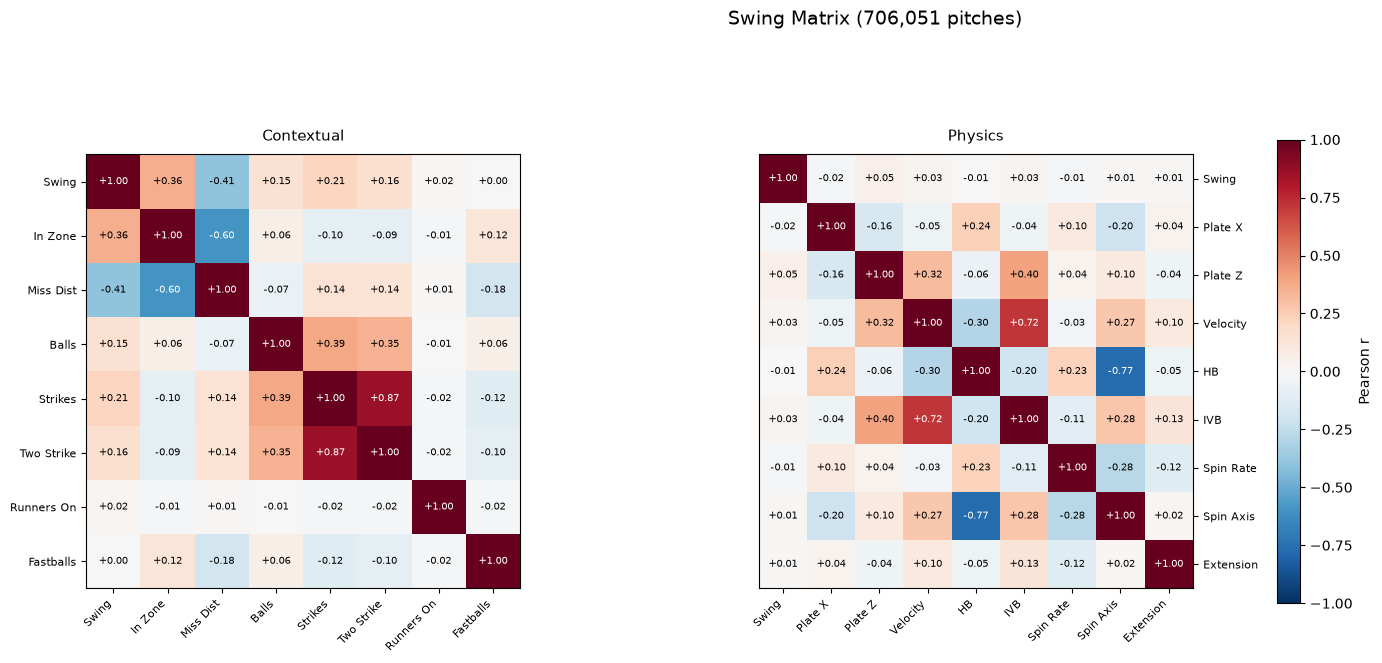

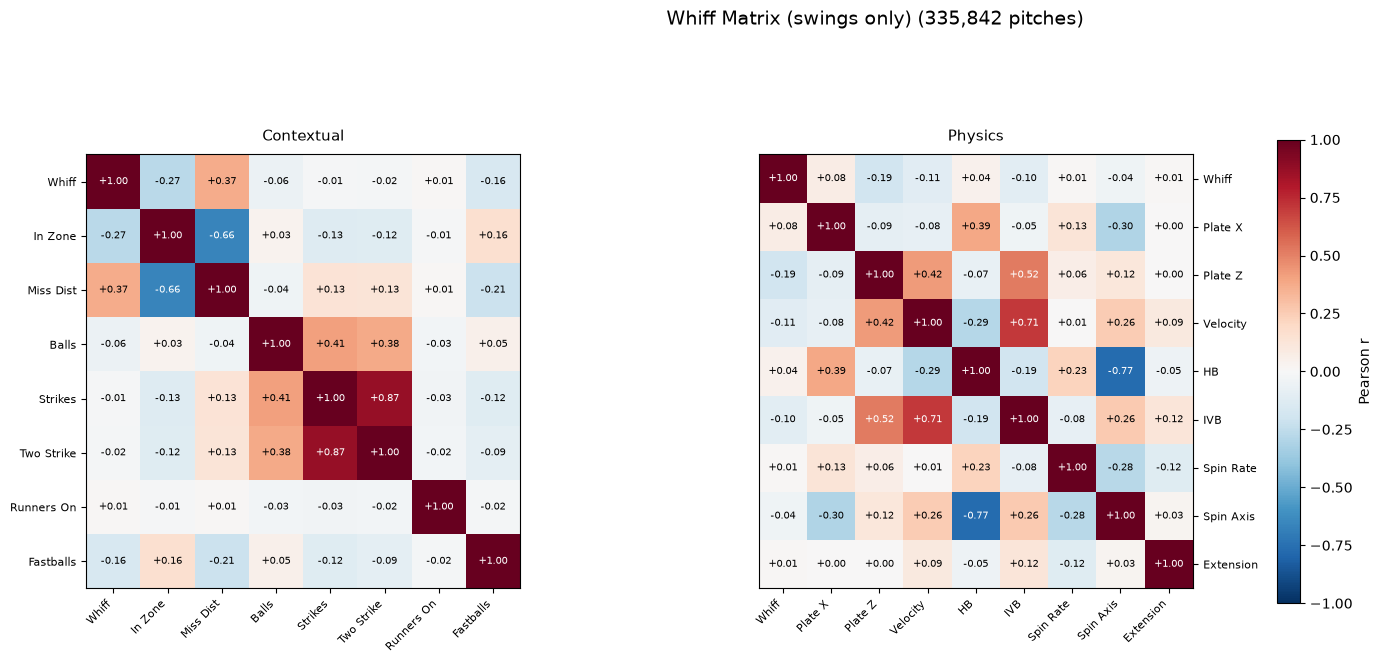

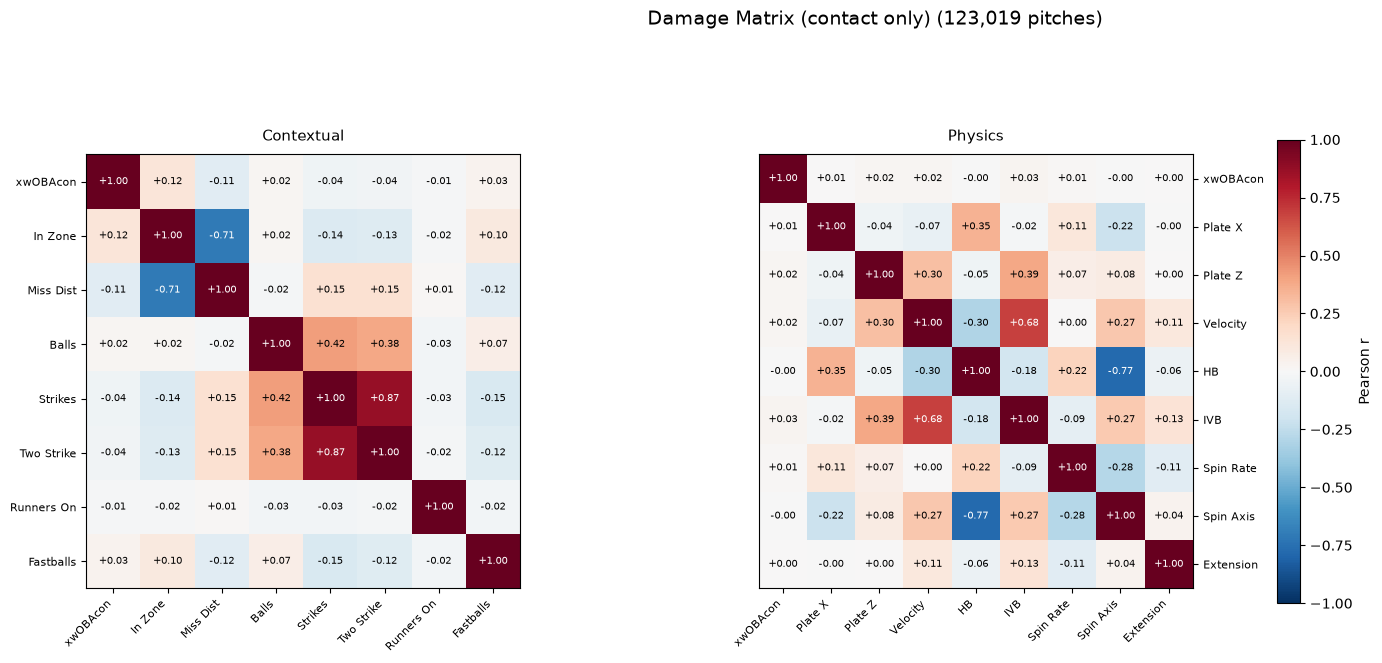

In [12]:
# Section 9 — outcome correlation matrices (static)
try:
    df
    PITCH_CATEGORIES
except NameError as exc:
    raise RuntimeError(
        "Run the Setup cell and the data load cell (Section 2) before this cell."
    ) from exc

import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

BIP_DESCRIPTIONS = {
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score",
}

FEATURE_LABELS = {
    "is_swing": "Swing",
    "is_whiff": "Whiff",
    "xwobacon": "xwOBAcon",
    "in_zone": "In Zone",
    "miss_dist_in": "Miss Dist",
    "balls": "Balls",
    "strikes": "Strikes",
    "is_two_strike": "Two Strike",
    "runners_on": "Runners On",
    "cat_fastball": "Fastballs",
    "plate_x": "Plate X",
    "plate_z": "Plate Z",
    "release_speed": "Velocity",
    "pfx_x": "HB",
    "pfx_z": "IVB",
    "release_spin_rate": "Spin Rate",
    "spin_axis": "Spin Axis",
    "release_extension": "Extension",
}

CONTEXT_COLS = [
    "in_zone",
    "miss_dist_in",
    "balls",
    "strikes",
    "is_two_strike",
    "runners_on",
    "cat_fastball",
]

PHYSICS_COLS = [
    "plate_x",
    "plate_z",
    "release_speed",
    "pfx_x",
    "pfx_z",
    "release_spin_rate",
    "spin_axis",
    "release_extension",
]

code_to_category = {
    code: category for category, codes in PITCH_CATEGORIES.items() for code in codes
}
competitive_codes = set(code_to_category)


def miss_distance_in(row: pd.Series) -> float:
    x, z = row["plate_x"], row["plate_z"]
    left, right = -0.708, 0.708
    bot, top = row["sz_bot"], row["sz_top"]
    x_out = max(0.0, left - x) if x < left else max(0.0, x - right)
    z_out = max(0.0, bot - z) if z < bot else max(0.0, z - top)
    return float(np.sqrt(x_out ** 2 + z_out ** 2) * 12.0)


def build_corr_frame(source: pd.DataFrame) -> pd.DataFrame:
    out = source[source["pitch_type"].isin(competitive_codes)].copy()
    out = out[out[["plate_x", "plate_z", "sz_top", "sz_bot"]].notna().all(axis=1)].copy()

    out["in_zone"] = out["is_in_zone"].astype(float)
    out["miss_dist_in"] = out.apply(miss_distance_in, axis=1).astype(float)
    out["balls"] = out["balls"].fillna(0).astype(float)
    out["strikes"] = out["strikes"].fillna(0).astype(float)
    out["is_two_strike"] = (out["strikes"] == 2).astype(float)
    out["runners_on"] = out[["on_1b", "on_2b", "on_3b"]].notna().sum(axis=1).astype(float)

    category = out["pitch_type"].map(code_to_category)
    out["cat_fastball"] = (category == "Fastballs").astype(float)

    for col in PHYSICS_COLS:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["xwobacon"] = pd.to_numeric(out["estimated_woba_using_speedangle"], errors="coerce")
    out["is_swing"] = out["is_swing"].astype(float)
    out["is_whiff"] = out["is_whiff"].astype(float)
    return out


def labeled_corr_matrix(frame: pd.DataFrame, target: str, features: list[str]) -> pd.DataFrame:
    cols = [target, *features]
    corr = frame[cols].dropna().corr()
    return corr.rename(index=FEATURE_LABELS, columns=FEATURE_LABELS)


def plot_corr_matrix(ax, corr: pd.DataFrame, title: str, *, y_labels_right: bool = False) -> None:
    n = len(corr)
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr.index, fontsize=8)
    if y_labels_right:
        ax.yaxis.tick_right()
        ax.tick_params(axis="y", labelright=True, labelleft=False, pad=4)
    ax.set_title(title, fontsize=11, pad=10)
    for i in range(n):
        for j in range(n):
            value = corr.values[i, j]
            color = "white" if abs(value) > 0.45 else "black"
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=7, color=color)
    return im


def plot_outcome_matrices(
    frame: pd.DataFrame,
    target: str,
    title: str,
    n_pitches: int,
) -> None:
    context_corr = labeled_corr_matrix(frame, target, CONTEXT_COLS)
    physics_corr = labeled_corr_matrix(frame, target, PHYSICS_COLS)

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    fig.suptitle(f"{title} ({n_pitches:,} pitches)", fontsize=14, y=1.02)

    im_left = plot_corr_matrix(axes[0], context_corr, "Contextual")
    im_right = plot_corr_matrix(axes[1], physics_corr, "Physics", y_labels_right=True)

    fig.tight_layout()
    fig.subplots_adjust(wspace=0.55, right=0.86)
    fig.colorbar(
        im_right,
        ax=axes.ravel().tolist(),
        location="right",
        pad=0.06,
        shrink=0.85,
        label="Pearson r",
    )
    plt.show()


corr_base = build_corr_frame(df)
swing_frame = corr_base.copy()
whiff_frame = corr_base[corr_base["is_swing"] == 1].copy()
damage_frame = corr_base[
    corr_base["description"].isin(BIP_DESCRIPTIONS) & corr_base["xwobacon"].notna()
].copy()

plot_outcome_matrices(swing_frame, "is_swing", "Swing Matrix", len(swing_frame))
plot_outcome_matrices(whiff_frame, "is_whiff", "Whiff Matrix (swings only)", len(whiff_frame))
plot_outcome_matrices(
    damage_frame, "xwobacon", "Damage Matrix (contact only)", len(damage_frame)
)


## Correlation Analysis: The Limits of Linear Math

To understand what drives batter behavior and contact quality, we filtered the dataset down to the most impactful contextual and physical features to reduce multicollinearity. The resulting matrices reveal a clear narrative: baseball outcomes are driven by context, and the physics are inherently non-linear.

### The Swing Matrix: Context is King
The decision to swing is heavily dictated by spatial boundaries and game context, while raw pitch physics matter very little in a purely linear sense.
* **Location Drives the Bat:** `In Zone` (+0.39) and `Miss Dist` (-0.41) are the strongest predictors. Hitters generally know the strike zone and swing at strikes.
* **Counts Force the Action:** `Strikes` (+0.21) and `Two Strike` (+0.16) show a clear positive correlation. As hitters get deeper into counts and face strikeout pressure, their swing rates mechanically increase to defend the plate. 
* **Physics are Irrelevant (Linearly):** Velocity, Spin Rate, and Break all show correlations near zero (+0.03 to -0.01). A hitter does not decide to swing *just* because a pitch is thrown hard; they swing because of where it is and what the count is.

### The Whiff Matrix: The Art of the Chase
Once a batter decides to swing, the paradigm flips. Generating a swing-and-miss is about getting the batter to swing at pitches they cannot reach.
* **The Chase Effect:** `Miss Dist` (+0.37) and `In Zone` (-0.30) completely invert from the Swing matrix. To get a whiff, pitchers need batters to swing at pitches further away from the center of the plate. 
* **Pitch Type Matters:** `Fastballs` show a negative correlation (-0.16) with whiffs. Batters naturally make more contact with heaters, meaning secondary pitches (breaking/off-speed) are the primary drivers of swing-and-miss.
* **Verticality:** `Plate Z` (-0.19) is the strongest physical correlate, indicating that lower pitches tend to generate more whiffs than higher pitches in this dataset.

### The Damage Matrix (xwOBAcon): The Non-Linear Wall
This matrix is the ultimate justification for tree-based modeling. The correlations are almost entirely flat, proving the necessity of advanced algorithms.
* **The Heart of the Plate:** The only variables that show any signal are `In Zone` (+0.11) and `Miss Dist` (-0.11). If a pitch is over the plate, it gets hit slightly harder.
* **The Mathematical Limit:** Every single physical variable (Velocity, Break, Spin) correlates between 0.00 and +0.03 with `xwOBAcon`. A 95 MPH fastball is not universally "good" or "bad"—its success depends entirely on its location and the game state. 

### Conclusion: Transitioning to Feature Engineering
Because linear models fail to capture the complex interactions between pitch physics and game context (e.g., a fastball up and in on an 0-2 count vs. a 3-0 count), we must engineer categorical states. By creating explicit Attack Regions (Heart, Shadow, Chase, Waste) and specific Count States, we can provide a decision tree the precise groupings it needs to map out these non-linear relationships.